## **Does job training increase earnings?**

Estimating the causal effect of a job training programme on incoming using multiple methods by comparing them.

## 

## **Exploring Lalonde**

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

from causalinference import CausalModel

In [5]:
lalonde = pd.read_csv('data input/lalonde.csv', index_col=0)
lalonde.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
5,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [12]:
cols = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75", "re78"]

lalonde.groupby("treat")[cols].mean()

,age,educ,black,hispan,married,nodegree,re74,re75,re78
treat,,,,,,,,,
0,28.030303,10.235431,0.202797,0.142191,0.512821,0.596737,5619.236506,2466.484443,6984.169742
1,25.816216,10.345946,0.843243,0.059459,0.189189,0.708108,2095.573689,1532.055314,6349.143530


In [13]:
lalonde.groupby('treat')['re78'].agg(['median','mean'])

,median,mean
treat,,
0,4975.505,6984.169742
1,4232.309,6349.143530


treat
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: re78, dtype: object

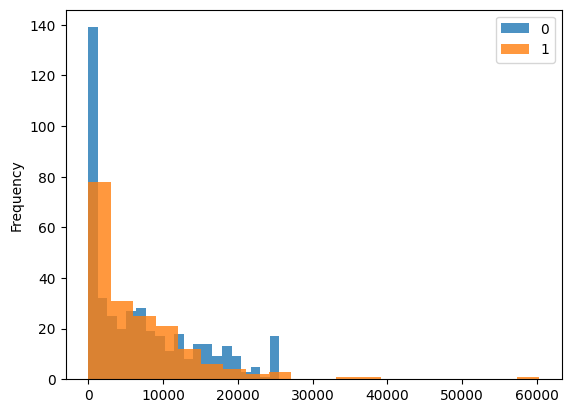

In [14]:
#The control group has higher earning that the treatment group. Does this imply the treatment had a negative impact?
lalonde.groupby('treat')['re78'].plot(kind='hist', bins=20, alpha=0.8, legend=True)

This dataset is not balanced. Indeed, people in the control group are very different from people in the test (treatment) group. Below is a plot of the different income distributions:

Key insights:
### 1. Demographics:

- Age: The treated group is younger → younger individuals were more likely to participate in the programme.
- Education: Almost identical across groups. Education appears to be fairly balanced.
- Race indicators: The treated group is substantially more likely to be Black, whereas it contains a lower proportion of Hispanic individuals → this indicates a strong signal of selection bias.
-  Marital status:The treated group is considerably less likely to be married. Programme participants are therefore more likely to be single, suggesting a different socio-economic profile.
- No degree: The treated group exhibits a higher proportion of individuals without a formal qualification, indicating slightly lower educational attainment.

### 2. Income history:

- re74: The treated group had approximately half the income of the control group prior to treatment.
- re75: Similarly, the treated group earns less in the pre-treatment period.
- re78 (post-treatment): On average, the treated group continues to earn less following the intervention.

Overall, the treated group started with substantially lower income levels and also exhibits lower post-intervention earnings.
The treated group is systematically “disadvantaged” prior to treatment. Consequently, a simple comparison of means would likely underestimate or bias the true effect of the programme.

This pattern suggests that groups were not randomly assigned and that the dataset is imbalanced.

### In summary:

- Treated group: younger, poorer, higher proportion of Black individuals, less likely to be married
- Control group: older, wealthier, more socio-economically stable

Can we compare outcomes directly?
No, this is not appropriate due to substantial covariate imbalance between the treated and control groups. In particular, pre-treatment income differs significantly, indicating the presence of selection bias.

A naive comparison of outcomes would therefore confound the true treatment effect with pre-existing differences in baseline characteristics.

# 1: What is the average treatment effect (ATE) of the training programme on 1978 eanings (re78)?

Info is retrieved from: https://rdrr.io/cran/MatchIt/man/lalonde.html
Treatment (treat): participated in training (1/0)
Outcome (re78): earnings after participation in the programme
Covariates: age, education, race, material status, past earnings (re74, re75)

ATE = E[Y(1)]−E[Y(0)]

- Treatment = job training programme
- Outcome = post-program income (e.g. earnings in 1978)

So ATE answers: On average, how much does the training program increase earnings for the whole population?
 

Covariates = observed characteristics we use to adjust
Confounders = covariates that actually bias treatment assignment + outcome -> Race and education are covariates, but they become confounders because they influence both participation in the program and earnings outcomes. If we don’t adjust for them, we attribute their effect to the treatment, which biases the ATE. -> Confounding is about bias, not about the variable itself.
The same variable can be:

just a covariate in one setting
a confounder in another

Control group = imperfect stand-in for counterfactual
ATE = causal effect we want after removing confounding

-> treatment assignment is not random. The treated and control groups differ systematically, so we’re not isolating the causal effect, but we’re mixing it with selection bias.
E = (Y1)-(Y0)
This compares outcomes for the same population under treatment vs no treatment
-> What we actually compute: In observational data, we instead compute:

E[Y∣D=1]−E[Y∣D=0]

Which compares two different groups of people.

Treatment is assumed to be unconfounded. Specifically, the dependence between the treatment assignment and the outcomes is only through something we observe, the covariates X.
More specifically, if we control for X, by ie looking across people with similar levels of X, then the difference between treated and control should be attributable to the treatment itself, as a randomised experiment is. If the assumption it doesn't hold our results could be completely wrong.

In [ ]:
cols = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75", "re78"]

lalonde.groupby("treat")[cols].mean()

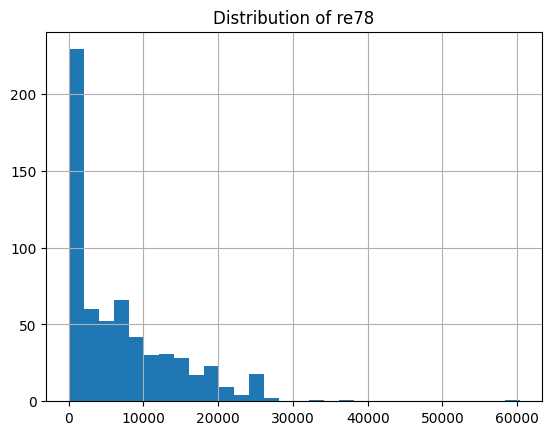

In [ ]:
lalonde["re78"].hist(bins=30)
plt.title("Distribution of re78")
plt.show()

In [34]:
from scipy.stats import shapiro

stat, p = shapiro(lalonde["re78"].sample(500))  # sample for speed
print(stat, p)

0.829200580662128 1.0380609904100316e-22


results show a clear non-normality result, and it’s exactly what we expect in LaLonde. 
- Null hypothesis: data is normally distributed
- p-value is extremely small -> reject normality -> re78 is not normally distributed

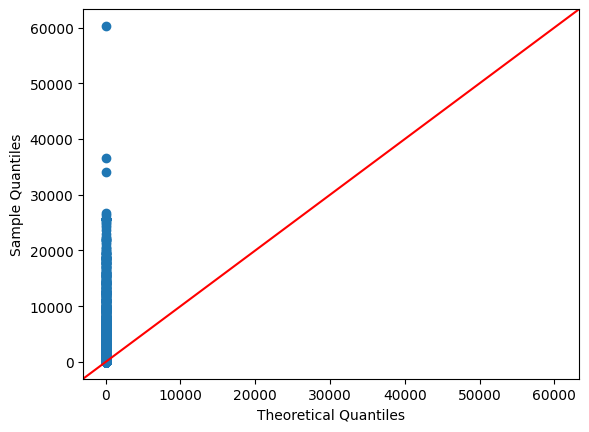

In [35]:
sm.qqplot(lalonde["re78"], line="45")
plt.show()

- strong deviation from line
- heavy clustering near low values
- extreme outliers (up to ~60000)

1. Strong right skew (positive skew) -> most people earn low/moderate income
few earn very high income
2. Heavy tails (outliers)
extreme high earners distort distribution
3. Non linearity vs normal curve
systematic deviation from theoretical quantiles


This does not invalidate OLS coefficients, however, it affects standard errors, confidence intervals and  p-values (in small samples)

# Adjusting for differences

In [24]:
#2. Compare with raw difference 
#treated_mean - control_mean 
Treatment_mean =lalonde.groupby("treat")["re78"].mean() 
print(Treatment_mean)

treat
0    6984.169742
1    6349.143530
Name: re78, dtype: float64


Raw difference=6349−6984≈−635 -> Participants who received treatment earned less than participants in the control group.

In [29]:
cols = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75", "re78"]

lalonde.groupby("treat")[cols].mean()

,age,educ,black,hispan,married,nodegree,re74,re75,re78
treat,,,,,,,,,
0,28.030303,10.235431,0.202797,0.142191,0.512821,0.596737,5619.236506,2466.484443,6984.169742
1,25.816216,10.345946,0.843243,0.059459,0.189189,0.708108,2095.573689,1532.055314,6349.143530


## OLS (Regression adjustment)

In [26]:
# Outcome 
Y = lalonde["re78"]  
#Treatment 
D = lalonde["treat"] 
# Covariates (X) (pre-treatment va) 
X = lalonde[[
    "age",
    "educ",
    "black",
    "hispan",
    "married",
    "re74",
    "re75"
]] 
#Intercept 
X = sm.add_constant(X)

In [30]:
X_full = sm.add_constant(pd.concat([D, X], axis=1))
model = sm.OLS(Y, X_full)
results = model.fit()


#Regression: 1. Used  𝑋 to explain differences in:
#- Y (outcome)
#- D (treatment selection)
#2. Removed those effects
#3. Estimated: “What is the effect of D on Y after removing X effects?”
results = model.fit() #regression
#Checks: Size of effect, sign & significance: 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     13.10
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.66e-17
Time:                        19:12:17   Log-Likelihood:                -6297.8
No. Observations:                 614   AIC:                         1.261e+04
Df Residuals:                     605   BIC:                         1.265e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
treat       1569.9573    777.480      2.019      0.0

OLS controls for pre-treatment covariates X, such as education and prior earnings, which influence both treatment assignment and outcomes. By accounting for these differences, the model isolates the variation in treatment that is not explained by X. The treatment coefficient therefore reflects the difference in outcomes between comparable individuals, reducing selection bias.
The raw difference suggests a negative effect due to selection bias, as treated individuals have worse baseline characteristics. After controlling for covariates using OLS, the estimated treatment effect becomes positive, indicating that the program increases earnings when comparing comparable individuals.

treat coef = 1569.96 (ß1)
p = 0.044 -> OLS removed the baseline differences in X (education, income, etc). After controlling for X, treatment increases earnings by ~1570. 

Confidence Interval:

With 95% confidence, the true treatment effect lies between 43€ and 3096€

-> The confidence interval indicates that while the estimated treatment effect is positive, there is substantial uncertainty in its magnitude. However, even this OLS estimate may not be reliable, as shown by LaLonde, because the method relies on the assumption that all confounders are observed. In practice, unobserved factors like motivation or ability can still bias the estimate, and model misspecification or lack of overlap can further distort results.


This model predicts that the Average Treatment Effect (ATE, the job training) is $1548 extra annual earnings. This is very different from our previous raw results predicting that the job training had negative effects on earnings.

Assuming that our model accurately describes the counterfactual X, CausalModel provides the 95% confidence interval. What this means is that, if we were to repeat this treatment experiment, in 95% of the cases the Average Treatment Effect would be within that interval. That doesn't mean that the true value is within that interval.

Based on the assumption that the residuals are normally distributed, the 95% confidence interval is calculated as:
AVG ± 1.96∗STD/√This model predicts that the Average Treatment Effect (ATE, the job training) is $1548 extra annual earnings. This is very different from our previous raw results predicting that the job training had negative effects on earnings!

Assuming that our model accurately describes the counterfactual X, CausalModel provides the 95% confidence interval. What this means is that, if we were to repeat this treatment experiment, in 95% of the cases the Average Treatment Effect would be within that interval. That doesn't mean that the true value is within that interval.

Based on the assumption that the residuals are normally distributed, the 95% confidence interval is calculated as:
AVG ± 1.96∗STD/√n

Assuming that we controlled for all the effects and did it well, it seems that the job training had a positive effect on earnings. Indeed, although the standard deviation is very large, the p value of 0.035 rejects the null hypothesis (no effect) with a confidence level of 97.5%. However, the truth is that we don't know if we modelled the counterfactual well, and this could change everything... As we will see later, estimators such as the Ordinary Least Square (OLS) estimator can behave poorly when there is not enough covariate overlap, and that's because the estimator needs to extrapolate too much from one group to another.

After linear adjustment, effect is strongly positive

Risk:
functional form assumption
extrapolation
sensitive to model specification

## Matching (Nearest neighbour)

In [54]:
X = lalonde[["age","educ","black","hispan","married","re74","re75"]]

treated = lalonde[lalonde["treat"]==1]
control = lalonde[lalonde["treat"]==0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[X.columns])

dist, idx = nn.kneighbors(treated[X.columns])
matched_control = control.iloc[idx.flatten()]

In [53]:
ATE_match = (treated["re78"].values - matched_control["re78"].values).mean()
ATE_match

np.float64(-90.956744864865)

ATE -91 After matching (using nearest neighbour) on observed characteristics, the programme shows a slightly negative effect (-91). This suggests poor matches in high dimensions,Euclidean distance not ideal or scale issues (income dominates distance)
, resulting in matching likely bad quality


Checks:
how many observations matched?
are treated vs matched control similar?

## Propensity Score

In [55]:
#Step 1: estimate p(X)

X = lalonde[["age","educ","black","hispan","married","re74","re75"]]
D = lalonde["treat"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

lalonde["pscore"] = logit.predict_proba(X)[:,1]

/Users/katharina.zimmerling/Library/CloudStorage/OneDrive-RapidDataGmbH/Dokumente/Sales prediction (Salesforce)/opportunity_prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/katharina.zimmerling/Library/CloudStorage/OneDrive-RapidDataGmbH/Dokumente/Sales prediction (Salesforce)/opportunity_prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/katharina.zimmerling/Library/CloudStorage/OneDrive-RapidDataGmbH/Dokumente/Sales prediction (Salesforce)/opportunity_prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/katharina.zimmerling/Library/CloudStorage/OneDrive-RapidDataGmbH/Dokumente/Sales p

In [ ]:
# Step 2: match on propensity score

In [56]:
treated = lalonde[lalonde["treat"]==1]
control = lalonde[lalonde["treat"]==0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])

dist, idx = nn.kneighbors(treated[["pscore"]])
matched_control = control.iloc[idx.flatten()]

In [ ]:
ATE_psm = (treated["re78"].values - matched_control["re78"].values).mean()
ATE_psm

np.float64(950.6090970270269)

After balancing treatment probability, programme increases earnings, suggesting that PSW reduces dimensionality problem and balance here is a stronger method than raw matching.

## Propensity Score Weighting (IPW)

In [58]:
ps = lalonde["pscore"]
D = lalonde["treat"]
Y = lalonde["re78"]

weights = np.where(D==1, 1/ps, 1/(1-ps))

In [59]:
ATE_ipw = np.sum(weights * D * Y) / np.sum(weights * D) - \
           np.sum(weights * (1-D) * Y) / np.sum(weights * (1-D))

ATE_ipw

np.float64(271.1887925200417)

3. IPW → +271
After reweighting, effect is small positive.

Why smaller?
uses full sample
averages more conservatively
sensitive to extreme weights

## Result summary table

| Method                    | ATE          |
| ------------------------- | ------------ |
| Matching (raw X)          | ** ~ -91**      |
| Propensity Score Matching | ** ~ +951**     |
| IPW (weighting)           | **~ +271**     |
| OLS (earlier)             | ~ **+1570**  |
| Raw difference            | **negative** |


The table suggests that results are very different from each other. Other than matching, results show a positive direction. Results vary and show unstability. Next, estimates depend heavily on the method ->strong indication of selection bias + model dependence.

Paradox: Even “suitable” methods give different answers on observational data.


In [4]:
weights = np.clip(weights, 0, 10)

NameError: name 'weights' is not defined

Testing:

“How sensitive is treatment effect to selection bias correction?”

Explain:
- raw ≠ causal
- OLS adjusts linearly
- matching compares individuals
- propensity score reduces dimensionality
- IPW reweights population